<a href="https://colab.research.google.com/github/write2chrischacko/Healthcare-Appointment-No-Show-Analysis-and-Prediction/blob/main/Healthcare_Appointment_No_Show_Analysis_%26_Prediction_CC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import matplotlib.cm as cm
import seaborn as sns
from scipy.stats import pearsonr
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind
from scipy.stats import f_oneway
import statsmodels.api as sm

In [ ]:
# Load dataset
df = pd.read_csv('/content/MedicalAppointment.csv')
display(df.head(10))

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No
5,9.598513e+13,5626772,F,2016-04-27T08:36:51Z,2016-04-29T00:00:00Z,76,REPÚBLICA,0,1,0,0,0,0,No
6,7.336882e+14,5630279,F,2016-04-27T15:05:12Z,2016-04-29T00:00:00Z,23,GOIABEIRAS,0,0,0,0,0,0,Yes
7,3.449833e+12,5630575,F,2016-04-27T15:39:58Z,2016-04-29T00:00:00Z,39,GOIABEIRAS,0,0,0,0,0,0,Yes
8,5.639473e+13,5638447,F,2016-04-29T08:02:16Z,2016-04-29T00:00:00Z,21,ANDORINHAS,0,0,0,0,0,0,No
9,7.812456e+13,5629123,F,2016-04-27T12:48:25Z,2016-04-29T00:00:00Z,19,CONQUISTA,0,0,0,0,0,0,No


In [ ]:
# Standardise column names
df.columns = (
    df.columns
      .str.upper()
      .str.replace(r'\s+', '_', regex=True)
      .str.replace('-', '_')
)

df = df.rename(columns={
    'PATIENTID':      'PATIENT_ID',
    'APPOINTMENTID':  'APPOINTMENT_ID',
    'SCHEDULEDDAY':   'SCHEDULED_DAY',
    'APPOINTMENTDAY': 'APPOINTMENT_DAY',
    'HIPERTENSION':   'HYPERTENSION',
    'HANDCAP':        'HANDICAP',
})

print("Columns:", df.columns.tolist(), "\n")

Columns: ['PATIENT_ID', 'APPOINTMENT_ID', 'GENDER', 'SCHEDULED_DAY', 'APPOINTMENT_DAY', 'AGE', 'NEIGHBOURHOOD', 'SCHOLARSHIP', 'HYPERTENSION', 'DIABETES', 'ALCOHOLISM', 'HANDICAP', 'SMS_RECEIVED', 'NO_SHOW', 'WAIT_DAYS', 'APPT_DOW', 'APPT_DOW_NAME', 'COMORBIDITY_COUNT', 'AGE_GROUP', 'WAITING_DAYS'] 



In [ ]:
# Checking Nulls
null_values = df.isnull().sum()
print("Null counts per column:")
print(null_values)
print(f"\nTotal nulls: {null_values.sum()}\n")

Null counts per column:
PATIENT_ID         0
APPOINTMENT_ID     0
GENDER             0
SCHEDULED_DAY      0
APPOINTMENT_DAY    0
AGE                0
NEIGHBOURHOOD      0
SCHOLARSHIP        0
HYPERTENSION       0
DIABETES           0
ALCOHOLISM         0
HANDICAP           0
SMS_RECEIVED       0
NO_SHOW            0
dtype: int64

Total nulls: 0



In [ ]:
# Fix data types
df['PATIENT_ID']     = df['PATIENT_ID'].astype(str)
df['APPOINTMENT_ID'] = df['APPOINTMENT_ID'].astype(str)

df['SCHEDULED_DAY']   = pd.to_datetime(df['SCHEDULED_DAY'],   utc=True).dt.tz_localize(None)
df['APPOINTMENT_DAY'] = pd.to_datetime(df['APPOINTMENT_DAY'], utc=True).dt.tz_localize(None)

df['NO_SHOW'] = (df['NO_SHOW'] == 'Yes').astype(int)

df['NEIGHBOURHOOD'] = df['NEIGHBOURHOOD'].str.strip().str.title()

print("Updated dtypes:")
print(df.dtypes, "\n")

Updated dtypes:
PATIENT_ID                 object
APPOINTMENT_ID             object
GENDER                     object
SCHEDULED_DAY      datetime64[ns]
APPOINTMENT_DAY    datetime64[ns]
AGE                         int64
NEIGHBOURHOOD              object
SCHOLARSHIP                 int64
HYPERTENSION                int64
DIABETES                    int64
ALCOHOLISM                  int64
HANDICAP                    int64
SMS_RECEIVED                int64
NO_SHOW                     int64
dtype: object 



In [ ]:
# Convert Handicap Values to True/False
df['HANDICAP'] = df['HANDICAP'].apply(lambda x: 1 if x > 0 else 0)

In [ ]:
df['HANDICAP'].value_counts()

,count
HANDICAP,
0,108286
1,2241


In [ ]:
df.describe()

,SCHEDULED_DAY,APPOINTMENT_DAY,AGE,SCHOLARSHIP,HYPERTENSION,DIABETES,ALCOHOLISM,HANDICAP,SMS_RECEIVED,NO_SHOW
count,110527,110527,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,2016-05-09 07:49:15.846273024,2016-05-19 00:57:50.008233472,37.088874,0.098266,0.197246,0.071865,0.030400,0.020276,0.321026,0.201933
min,2015-11-10 07:13:56,2016-04-29 00:00:00,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2016-04-29 10:27:01,2016-05-09 00:00:00,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2016-05-10 12:13:17,2016-05-18 00:00:00,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2016-05-20 11:18:37,2016-05-31 00:00:00,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,2016-06-08 20:07:23,2016-06-08 00:00:00,115.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
std,NaN,NaN,23.110205,0.297675,0.397921,0.258265,0.171686,0.140942,0.466873,0.401444


In [ ]:
df.describe(include='object')

,PATIENT_ID,APPOINTMENT_ID,GENDER,NEIGHBOURHOOD
count,110527,110527,110527,110527
unique,62299,110527,2,81
top,822145925426128.0,5629448,F,Jardim Camburi
freq,88,1,71840,7717


In [ ]:
print(f"\nAge < 0  : {(df['AGE'] < 0).sum()}")
print(f"Age > 100: {(df['AGE'] > 100).sum()}")

df = df[df['AGE'] >= 0].reset_index(drop=True)      # drop the negative age record
df['AGE'] = df['AGE'].clip(upper=100)                # cap implausible values


Age < 0  : 1
Age > 100: 7


In [ ]:
df['WAIT_DAYS'] = (df['APPOINTMENT_DAY'] - df['SCHEDULED_DAY']).dt.days

neg_wait = df['WAIT_DAYS'] < 0
print(f"\nRows where appointment precedes scheduling (true errors): {neg_wait.sum()}")
if neg_wait.sum():
    df = df[~neg_wait].reset_index(drop=True)
    print("Dropped.")


Rows where appointment precedes scheduling (true errors): 38567
Dropped.


In [ ]:
dupes = df.duplicated(subset='APPOINTMENT_ID').sum()
print(f"\nDuplicate APPOINTMENT_IDs: {dupes}")
if dupes:
    df = df.drop_duplicates(subset='APPOINTMENT_ID').reset_index(drop=True)


Duplicate APPOINTMENT_IDs: 0


In [ ]:
# Day of week the appointment falls on (0=Mon … 6=Sun)
df['APPT_DOW']     = df['APPOINTMENT_DAY'].dt.dayofweek
df['APPT_DOW_NAME']= df['APPOINTMENT_DAY'].dt.day_name()

# Comorbidity count per patient-visit
df['COMORBIDITY_COUNT'] = (
    df[['HYPERTENSION', 'DIABETES', 'ALCOHOLISM']].sum(axis=1).astype('uint8')
)

# Age buckets
df['AGE_GROUP'] = pd.cut(
    df['AGE'],
    bins=[-1, 12, 17, 35, 60, 100],
    labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']
)

print("\nEngineered columns added: WAIT_DAYS, APPT_DOW, APPT_DOW_NAME, COMORBIDITY_COUNT, AGE_GROUP")


Engineered columns added: WAIT_DAYS, APPT_DOW, APPT_DOW_NAME, COMORBIDITY_COUNT, AGE_GROUP


In [ ]:
print(df[["APPOINTMENT_DAY", "APPT_DOW", "APPT_DOW_NAME"]].tail(50))

      APPOINTMENT_DAY  APPT_DOW APPT_DOW_NAME
71909      2016-06-08         2     Wednesday
71910      2016-06-08         2     Wednesday
71911      2016-06-08         2     Wednesday
71912      2016-06-01         2     Wednesday
71913      2016-06-08         2     Wednesday
71914      2016-06-08         2     Wednesday
71915      2016-06-01         2     Wednesday
71916      2016-06-01         2     Wednesday
71917      2016-06-08         2     Wednesday
71918      2016-06-08         2     Wednesday
71919      2016-06-07         1       Tuesday
71920      2016-06-06         0        Monday
71921      2016-06-06         0        Monday
71922      2016-06-06         0        Monday
71923      2016-06-06         0        Monday
71924      2016-06-06         0        Monday
71925      2016-06-06         0        Monday
71926      2016-06-06         0        Monday
71927      2016-06-06         0        Monday
71928      2016-06-06         0        Monday
71929      2016-06-06         0   

In [ ]:
df.to_csv('cleaned_noshow_data.csv', index=False)

# Data Cleaning Summary

- Imported the required Python libraries such as NumPy, Pandas, Matplotlib, and Seaborn.
- Loaded the healthcare appointment dataset into a Pandas DataFrame.
- Standardised column names for better readability and consistency.
- Checked for missing/null values in all columns.
- Verified and corrected data types where required.
- Identified and checked duplicate Appointment IDs.
- Handled invalid and inconsistent values such as negative ages.
- Converted date columns into datetime format for analysis.
- Created additional features such as:
  - Waiting Days
  - Appointment Day Name
  - Appointment Weekday
- Verified dataset structure using descriptive statistics and data inspection methods.


# **Exploratory Data Analysis**
## **Descriptive Analysis**
Descriptive analysis was performed to understand the overall structure, characteristics, and distribution of the healthcare appointment dataset.

The analysis focused on:

- Demographic distribution of patients
- Appointment behaviour patterns
- Medical condition distribution
- SMS notification patterns
- Waiting time analysis
- Neighbourhood-wise appointment trends

Various statistical methods and visualisations such as count plots, histograms, boxplots, and bar charts were used to identify trends and patterns within the dataset.

The descriptive analysis provided a foundational understanding of the factors that may influence patient appointment attendance behaviour.


In [ ]:
sns.set_theme(style='whitegrid', palette='Paired')
plt.rcParams.update({
    'figure.dpi'       : 120,
    'figure.facecolor' : '#F8F9FA',
    'axes.facecolor'   : '#FFFFFF',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.titlesize'   : 13,
    'axes.titleweight' : 'bold',
    'axes.labelsize'   : 11,
    'xtick.labelsize'  : 10,
    'ytick.labelsize'  : 10,
    'font.family'      : 'DejaVu Sans',
})

ACCENT  = '#2563EB'
DANGER  = '#DC2626'
TEAL    = '#0D9488'
AMBER   = '#D97706'
PURPLE  = '#7C3AED'
PALETTE = [ACCENT, DANGER]


In [ ]:
total = len(df)

print(f"\nTotal Patients : {total:,}")

print(f"\nFinancial")
print(f"Scholarship: {df['SCHOLARSHIP'].sum():,} ({df['SCHOLARSHIP'].mean()*100:.1f}%)")

print(f"\nDisability")
print(f"Handicap: {df['HANDICAP'].sum():,} ({df['HANDICAP'].mean()*100:.1f}%)")

print(f"\nMedical Conditions")
print(f"Hypertension: {df['HYPERTENSION'].sum():,} ({df['HYPERTENSION'].mean()*100:.1f}%)")
print(f"Diabetes: {df['DIABETES'].sum():,} ({df['DIABETES'].mean()*100:.1f}%)")
print(f"Alcoholism: {df['ALCOHOLISM'].sum():,} ({df['ALCOHOLISM'].mean()*100:.1f}%)")

print(f"\nCommunication")
print(f"SMS Received: {df['SMS_RECEIVED'].sum():,} ({df['SMS_RECEIVED'].mean()*100:.1f}%)")


Total Patients : 71,959

Financial
Scholarship: 6,671 (9.3%)

Disability
Handicap: 1,307 (1.8%)

Medical Conditions
Hypertension: 15,032 (20.9%)
Diabetes: 5,377 (7.5%)
Alcoholism: 1,822 (2.5%)

Communication
SMS Received: 35,482 (49.3%)


In [ ]:
total       = len(df)
no_show_n   = df['NO_SHOW'].sum()
show_n      = total - no_show_n
no_show_pct = no_show_n / total * 100

print(f"  Total appointments: {total:>10,}")
print(f"  Showed up (0): {show_n:>10,}  ({100 - no_show_pct:.1f}%)")
print(f"  No-show    (1): {no_show_n:>10,}  ({no_show_pct:.1f}%)")

  Total appointments:     71,959
  Showed up (0):     51,437  (71.5%)
  No-show    (1):     20,522  (28.5%)


## Insight: Gender Distribution

Female patients are double that of male patients.

the no-show rate (1) versus show up rate (0) appears consistent between genders.
- Females: ~28% No-Show rate
- Males: ~28% No-Show rate

## Insight: Age Distribution

Patients are distributed across all age groups evenly with peak in infants and newborns and another high-density cluster around ages 50–60.

Right Skew: The frequency tapers off after age 70, reflecting the natural decline in older populations.

## Insight: Age Boxplot

- The median patient age is approximately 38–40 years old.
- IQR: 50% of the patients fall between the ages of 18 and 56.
- No Outliers.

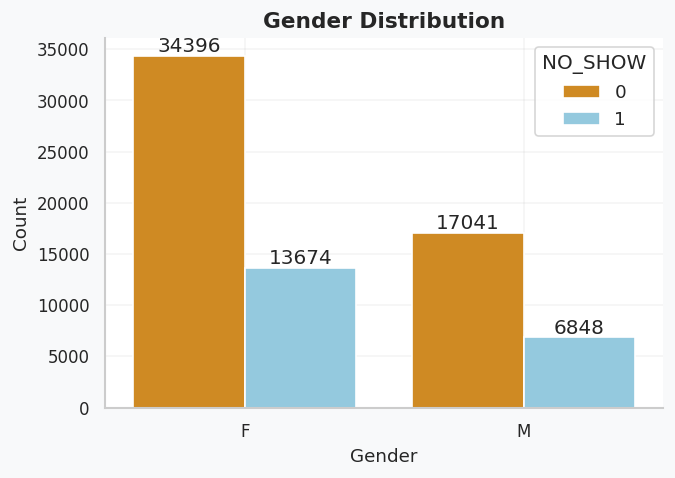

In [ ]:
# Gender Distribution
plt.figure(figsize=(6,4))
ax = sns.countplot(data=df, x='GENDER', palette=['#ec9006', 'skyblue'], hue='NO_SHOW')

# Add value counts on bars
for container in ax.containers:
    ax.bar_label(container)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.grid(True, alpha=0.2)
plt.show()

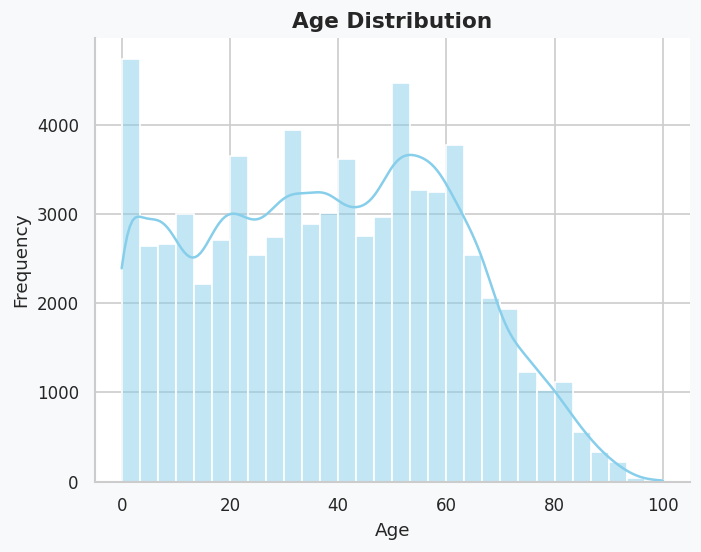

In [ ]:
# Age distribution
sns.histplot(df['AGE'], bins=30, kde=True, color='skyblue')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

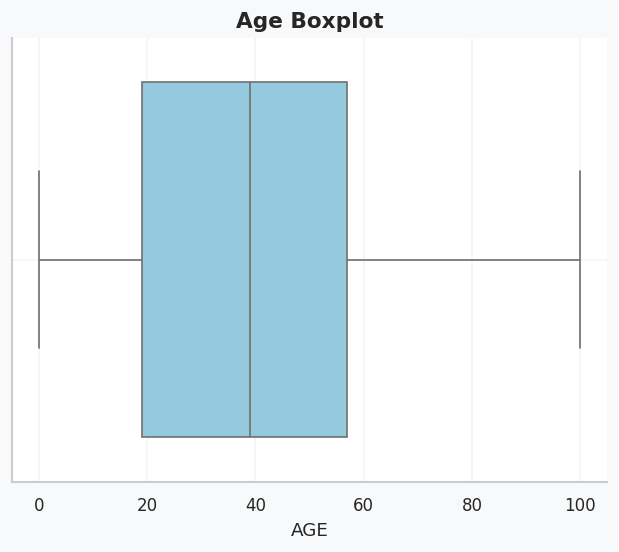

In [ ]:
sns.boxplot(x=df['AGE'], color='skyblue')

plt.title("Age Boxplot")
plt.grid(True, alpha=0.2)
plt.show()

## Insight: Neighbourhood Distribution

- Jardim Camburi has the highest number of appointments (5,000).
- Maria Ortiz, Resistencia and Jardim Da Penha are the next of high demand areas followed by a gradual decline and plateau.
- This indicates that majority of the healthcare resources are available in these top 4 locations.

## Insight: Scholarship Distribution

- Majority of patients (over 90%) are not enrolled in the Scholarship program.
- Only about 9.3% (6,671 out of 71,959 total) of the patients in this dataset receive this financial assistance.

In [ ]:
# Top 10 neighbourhoods
top_locations = df['NEIGHBOURHOOD'].value_counts().head(10)

print(top_locations)

NEIGHBOURHOOD
Jardim Camburi       5213
Maria Ortiz          3730
Resistência          2818
Jardim Da Penha      2655
Itararé              2381
Centro               2270
Tabuazeiro           1924
Jesus De Nazareth    1755
Bonfim               1708
Caratoíra            1691
Name: count, dtype: int64


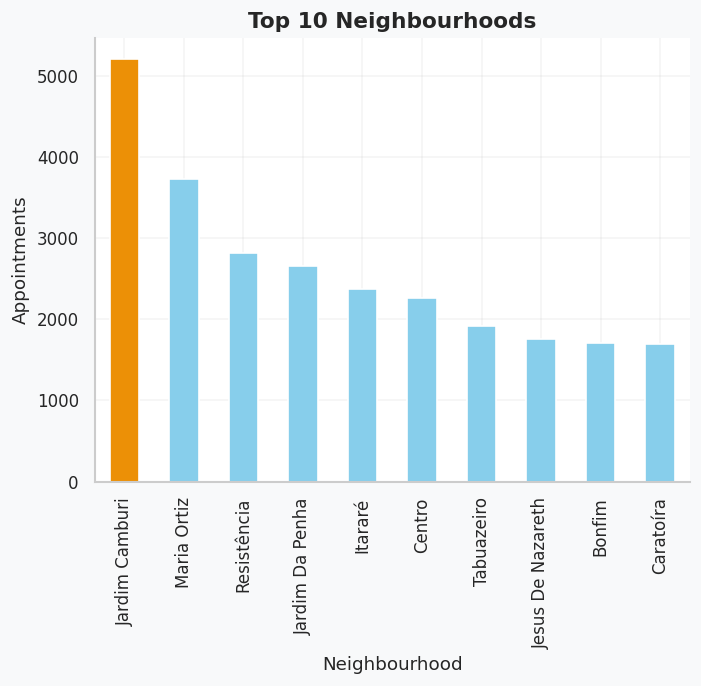

In [ ]:
colors = ['skyblue'] * len(top_locations)
colors[0] = '#ec9006'

top_locations.plot(kind='bar', color=colors)

plt.title("Top 10 Neighbourhoods")
plt.xlabel("Neighbourhood")
plt.ylabel("Appointments")
plt.xticks(rotation=90)
plt.grid(True, alpha=0.2)
plt.show()

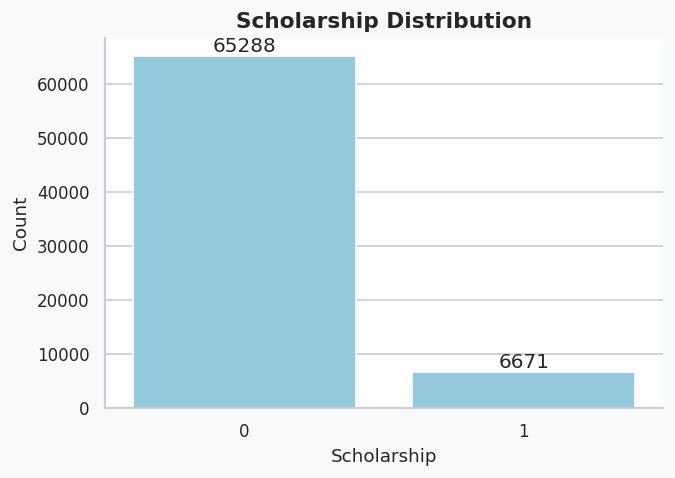

In [ ]:
# Scholarship distribution
plt.figure(figsize=(6,4))

ax = sns.countplot(data=df, x='SCHOLARSHIP', color='skyblue')
for container in ax.containers:
    ax.bar_label(container)

plt.title("Scholarship Distribution")
plt.xlabel("Scholarship")
plt.ylabel("Count")
plt.show()

In [ ]:
scholarship_percentage = (df['SCHOLARSHIP'].mean()) * 100
print("Percentage of patients with scholarship:", round(scholarship_percentage, 2), "%")

Percentage of patients with scholarship: 9.27 %


## Medical Conditions Insight

- Trend: patients with chronic medical conditions are more likely to show up.
- Hypertension is the most common condition (~21%) followed by Diabetes (7.5%).
- Alcoholism and Handicapped individuals are rare.
- No-Show rate of alcoholic patients is about 34%, which is slightly higher than other categories.

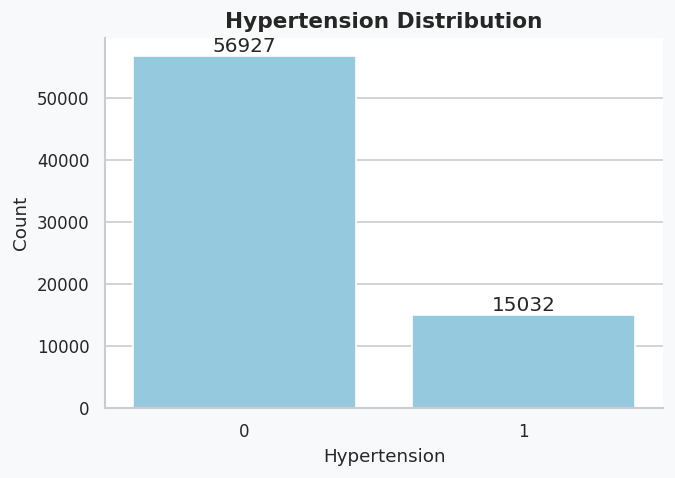

In [ ]:
# Hypertension Distribution
plt.figure(figsize=(6,4))

ax= sns.countplot(data=df, x='HYPERTENSION', color='skyblue')
for container in ax.containers:
    ax.bar_label(container)

plt.title("Hypertension Distribution")
plt.xlabel("Hypertension")
plt.ylabel("Count")
plt.show()

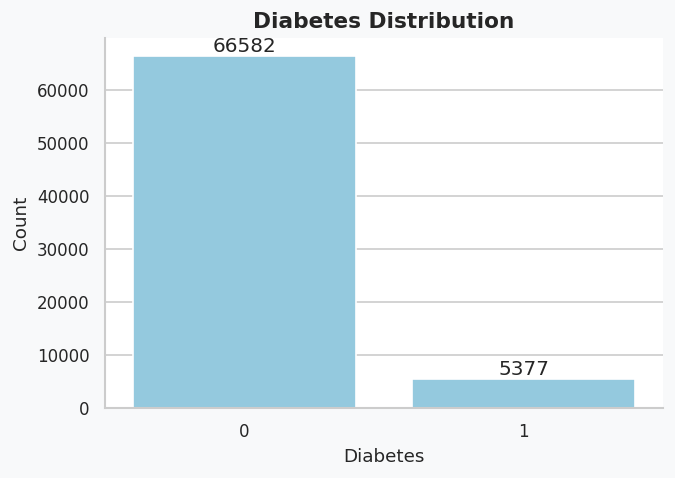

In [ ]:
# Diabetes Distribution
plt.figure(figsize=(6,4))

ax = sns.countplot(data=df, x='DIABETES', color='skyblue')
for container in ax.containers:
    ax.bar_label(container)

plt.title("Diabetes Distribution")
plt.xlabel("Diabetes")
plt.ylabel("Count")
plt.show()

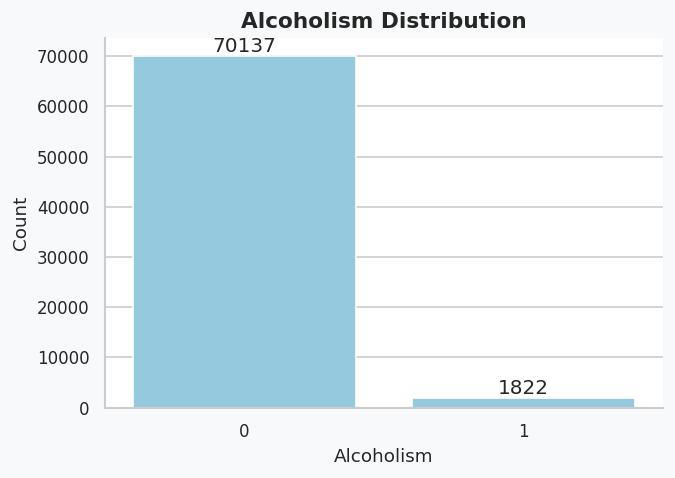

In [ ]:
# Alcoholism Distribution
plt.figure(figsize=(6,4))

ax = sns.countplot(data=df, x='ALCOHOLISM', color='skyblue')
for container in ax.containers:
    ax.bar_label(container)

plt.title("Alcoholism Distribution")
plt.xlabel("Alcoholism")
plt.ylabel("Count")
plt.show()

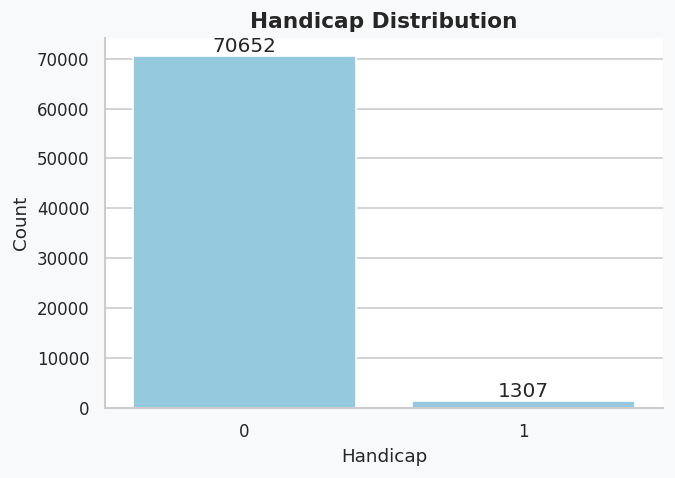

In [ ]:
# Handicap Distribution
plt.figure(figsize=(6,4))

ax = sns.countplot(data=df, x='HANDICAP', color='skyblue')

for container in ax.containers:
    ax.bar_label(container)

plt.title("Handicap Distribution")
plt.xlabel("Handicap")
plt.ylabel("Count")

plt.show()

In [ ]:
columns = ['HYPERTENSION', 'DIABETES', 'ALCOHOLISM', 'HANDICAP']

for col in columns:
    Percentage = df[col].mean() * 100
    print(f"{col} Percentage: {Percentage:.2f}%")

HYPERTENSION Percentage: 20.89%
DIABETES Percentage: 7.47%
ALCOHOLISM Percentage: 2.53%
HANDICAP Percentage: 1.82%


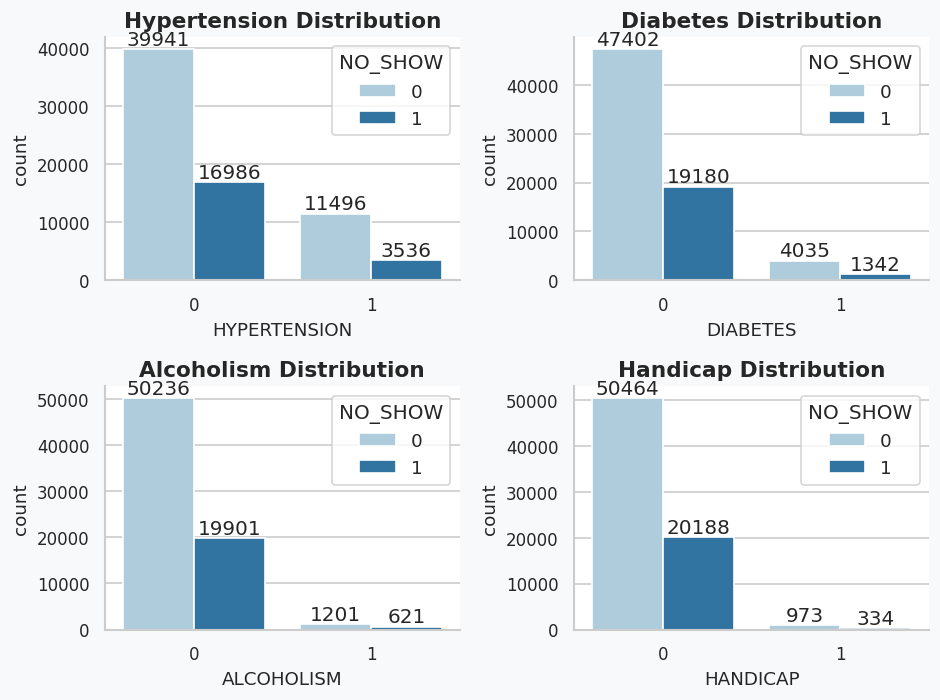

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(8,6))

# Hypertension
ax1 = sns.countplot(data=df, x='HYPERTENSION', ax=axes[0,0], hue='NO_SHOW')
axes[0,0].set_title("Hypertension Distribution")
for container in ax1.containers:
    ax1.bar_label(container)

# Diabetes
ax2 = sns.countplot(data=df, x='DIABETES', ax=axes[0,1], hue='NO_SHOW')
axes[0,1].set_title("Diabetes Distribution")
for container in ax2.containers:
    ax2.bar_label(container)

# Alcoholism
ax3 = sns.countplot(data=df, x='ALCOHOLISM', ax=axes[1,0], hue='NO_SHOW')
axes[1,0].set_title("Alcoholism Distribution")
for container in ax3.containers:
    ax3.bar_label(container)

# Handicap
ax4 = sns.countplot(data=df, x='HANDICAP', ax=axes[1,1], hue='NO_SHOW')
axes[1,1].set_title("Handicap Distribution")
for container in ax4.containers:
    ax4.bar_label(container)

plt.tight_layout()
plt.show()

In [ ]:
# Columns to analyse
columns = ['HYPERTENSION', 'DIABETES', 'ALCOHOLISM', 'HANDICAP']

for col in columns:
    print(f"\n")
    percentage_table = pd.crosstab(df[col], df['NO_SHOW'], normalize='index') * 100
    percentage_table.columns = ['Show %', 'No-Show %']
    percentage_table = percentage_table.round(2)
    print(percentage_table)



              Show %  No-Show %
HYPERTENSION                   
0              70.16      29.84
1              76.48      23.52


          Show %  No-Show %
DIABETES                   
0          71.19      28.81
1          75.04      24.96


            Show %  No-Show %
ALCOHOLISM                   
0            71.63      28.37
1            65.92      34.08


          Show %  No-Show %
HANDICAP                   
0          71.43      28.57
1          74.45      25.55


## Insight: SMS Notification Analysis

Although the rate of No-Show is about the same, patients who recieve and SMS reminder are have a slightly higher chance of showing up to their appointment.

## Insight: Appointment Over Time

- Volume of appointments is generally stable, oscillating between 2,500 and 3,000 per day.
- 15th May, 2016 (Sunday) saw a drastic decline in appointments, probably due to weekend slump and potential local holiday.

## Insight: Waiting Time Analysis

- Wednesday have the highest appointments with 32%, followed my Tuesday (22.8%) and Monday (20.2%).
- The wait day distribution is heavily right skewed, concentrated at 0-20 days.
- There is a cluster of outliers starting after 50 days. This implies that although majority of patients wait a short period of time, there is a significant number of patients who entend their appointment.


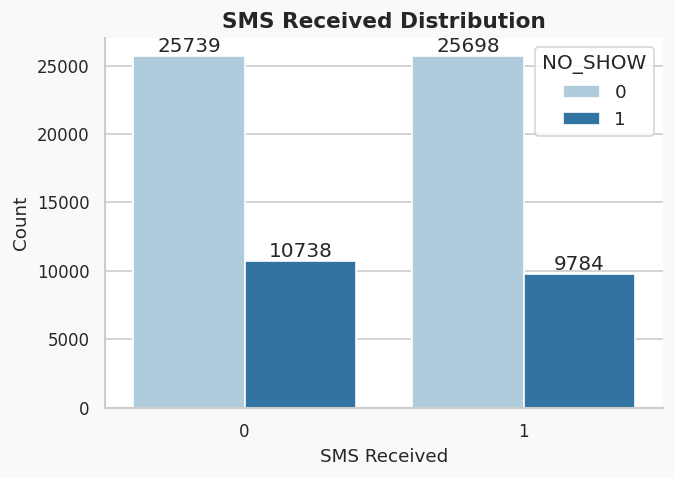

In [ ]:
# SMS Received Distribution
plt.figure(figsize=(6,4))

ax = sns.countplot(data=df, x='SMS_RECEIVED', hue='NO_SHOW')
for container in ax.containers:
    ax.bar_label(container)

plt.title("SMS Received Distribution")
plt.xlabel("SMS Received")
plt.ylabel("Count")
plt.show()

In [ ]:
sms_percentage = (df['SMS_RECEIVED'].mean()) * 100
print("Percentage of patients recieved SMS:", round(sms_percentage, 2), "%")

sms_percentage = pd.crosstab(
    df['SMS_RECEIVED'],
    df['NO_SHOW'],
    normalize='index') * 100

sms_percentage.columns = ['Show %', 'No-Show %']
sms_percentage = sms_percentage.round(2)

print(sms_percentage)

Percentage of patients recieved SMS: 49.31 %
              Show %  No-Show %
SMS_RECEIVED                   
0              70.56      29.44
1              72.43      27.57


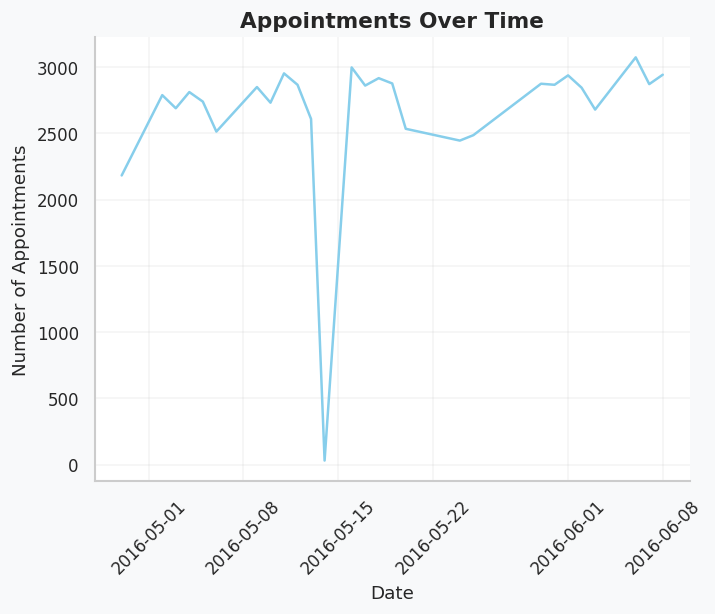

In [ ]:
# Appointment trend
appointments_per_day = df.groupby(
    df['APPOINTMENT_DAY'].dt.date
).size()

appointments_per_day.plot(color='skyblue')

plt.title("Appointments Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Appointments")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.2)
plt.show()

In [ ]:
# Create Waiting Days column
df['WAITING_DAYS'] = (
    df['APPOINTMENT_DAY'] - df['SCHEDULED_DAY']
).dt.days

df = df[df['WAITING_DAYS'] >= 0]    # Remove negative wait days

df['WAITING_DAYS'].describe()

,WAITING_DAYS
count,71959.000000
mean,14.642018
std,16.494334
min,0.000000
25%,3.000000
50%,8.000000
75%,21.000000
max,178.000000


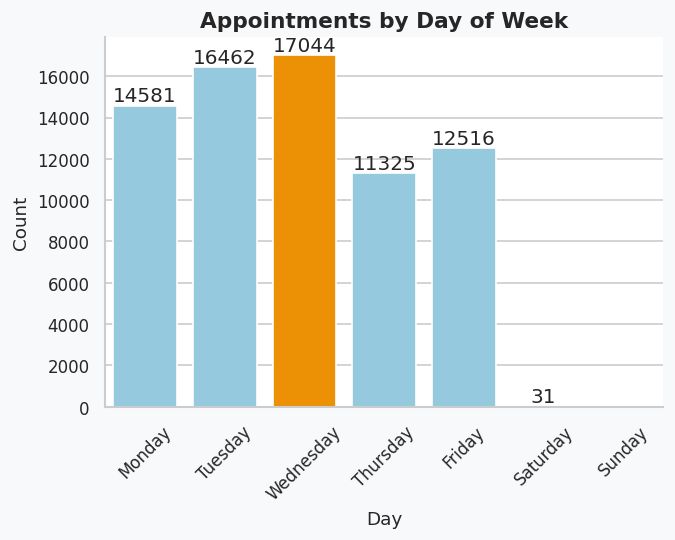

In [ ]:
plt.figure(figsize=(6,4))
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

ax = sns.countplot(
    data=df,
    x='APPT_DOW_NAME',
    order=day_order,
    color='skyblue'
)

heights = [p.get_height() for p in ax.patches]
max_height = max(heights)
for p in ax.patches:
    if p.get_height() == max_height:
        p.set_facecolor('#ec9006')

for container in ax.containers:
    ax.bar_label(container)

plt.title("Appointments by Day of Week")
plt.xlabel("Day")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Percentage distribution of appointments by Day of Week

dow_percentage = (
    df['APPT_DOW_NAME']
    .value_counts(normalize=True) * 100
).round(2)

print(dow_percentage)

APPT_DOW_NAME
Wednesday    23.69
Tuesday      22.88
Monday       20.26
Friday       17.39
Thursday     15.74
Saturday      0.04
Name: proportion, dtype: float64


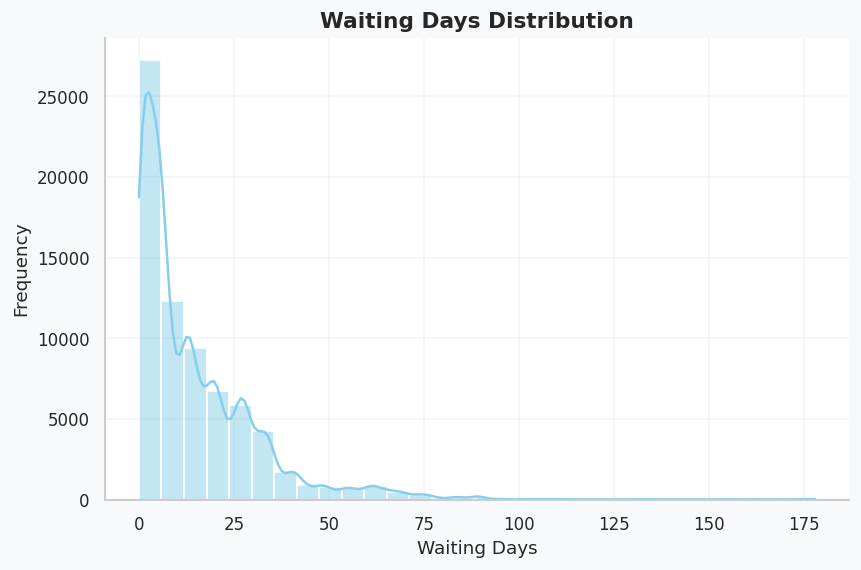

In [ ]:
plt.figure(figsize=(8,5))

ax = sns.histplot(data=df, x='WAITING_DAYS', bins=30, kde=True, color='skyblue')

plt.title("Waiting Days Distribution")
plt.xlabel("Waiting Days")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.2)
plt.show()

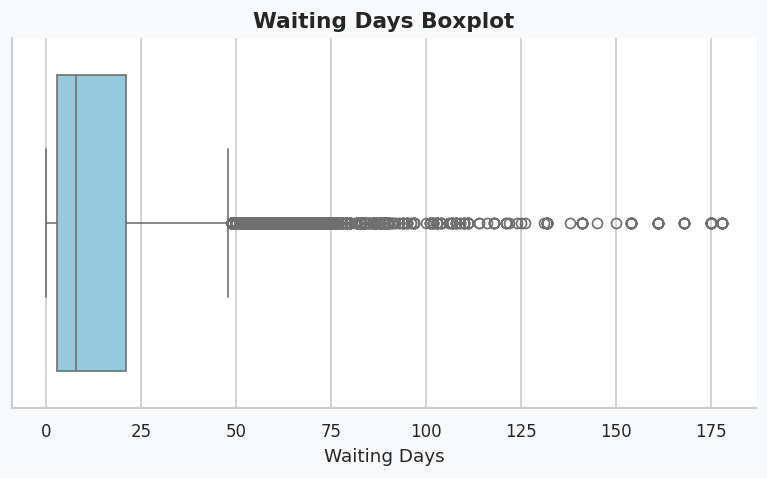

In [ ]:
plt.figure(figsize=(8,4))

sns.boxplot(data=df, x='WAITING_DAYS', color='skyblue')

plt.title("Waiting Days Boxplot")
plt.xlabel("Waiting Days")

plt.show()

## Correlation Heatmap

- Hypertension and Age (0.50): Strong positive correlation, indicating hypertension to affect patients as they grow older.
- Hypertension and Diabetes (0.43): Patients affected by one disease is likely to have the other.
- Comorbidity: High correlation with Hypertension (0.88), Diabetes (0.73).
- No-Show: Negative correlation with Age (-0.10).
- SMS Received: Slightly positive correlation with wait days, indicating slightly more messages are sent to those with longer wait days.

In [ ]:
print("Average Waiting Days:", round(df['WAITING_DAYS'].mean(), 2))
print("Maximum Waiting Days:", df['WAITING_DAYS'].max())
print("Minimum Waiting Days:", df['WAITING_DAYS'].min())

Average Waiting Days: 14.64
Maximum Waiting Days: 178
Minimum Waiting Days: 0


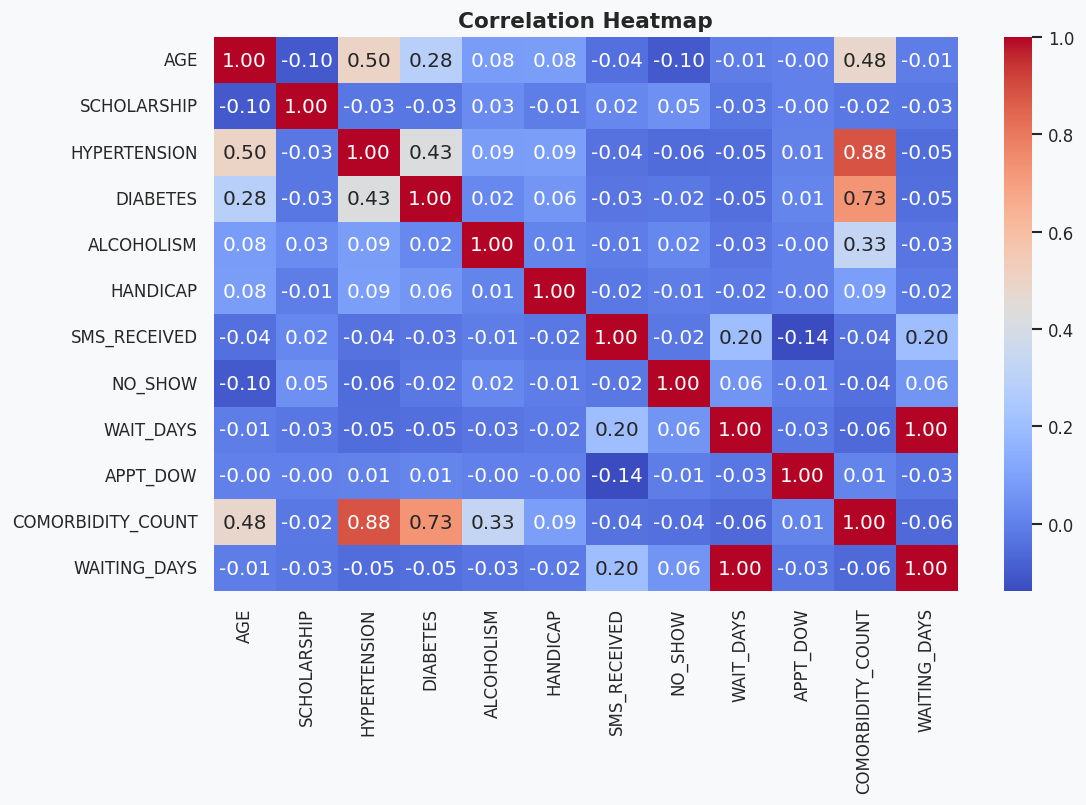

In [ ]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

## **Target Variable Analysis**

Target variable analysis was performed on the `NO_SHOW` column to understand patient attendance behaviour.

The analysis examined relationships between appointment attendance and various factors such as:

- Age
- Gender
- Waiting Days
- SMS Notifications
- Medical Conditions
- Appointment Day
- Neighbourhood

## Insights
### No Show vs. Age
- The curve between the ages of 20 and 40 suggests that young adults who may have more volatile work schedules or childcare conflicts are the most likely to miss appointments.
- As age increases beyond 60, the No-Show curve drops off much faster than the Show curve. Senior citizens are your most reliable patients, likely because they perceive their health needs as more urgent or have more predictable schedules.
- There is a high volume of appointments for children aged 0–5 (pediatric visits). While the show rate is high, the no-show volume is also high here simply due to the sheer number of appointments booked for this age group.
- Communication strategies should be tailored. For the 20–40 age group, the clinic might consider digital-first reminders (app notifications/SMS) that allow for easy one-click rescheduling.

### No Show vs. Waiting Time
- The median waiting time for the No-Show (1) group is visibly higher than that of the Show (0) group.
- The upper quartile (the top of the box) for No-Shows extends much further than the Show group. This indicates that as wait times cross into the 20+ day range, the risk of a no-show escalates significantly.
- The clinic should prioritise "Short-Fill" lists or more aggressive reminder schedules for any appointment with a lead time greater than 15 days, as this is where the distribution shifts toward non-attendance.

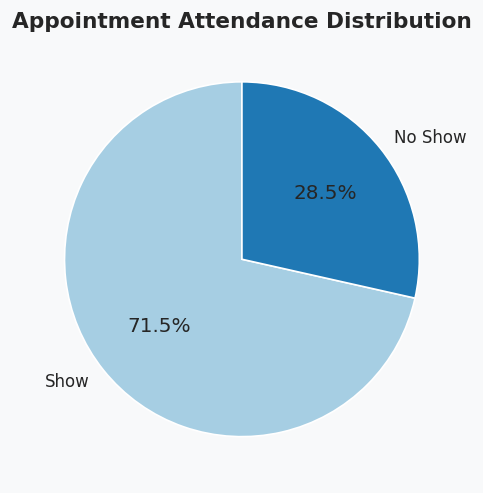

In [ ]:
labels = ['Show', 'No Show']
sizes = df['NO_SHOW'].value_counts().sort_index()

plt.pie(sizes,
        labels=labels,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Appointment Attendance Distribution")
plt.show()

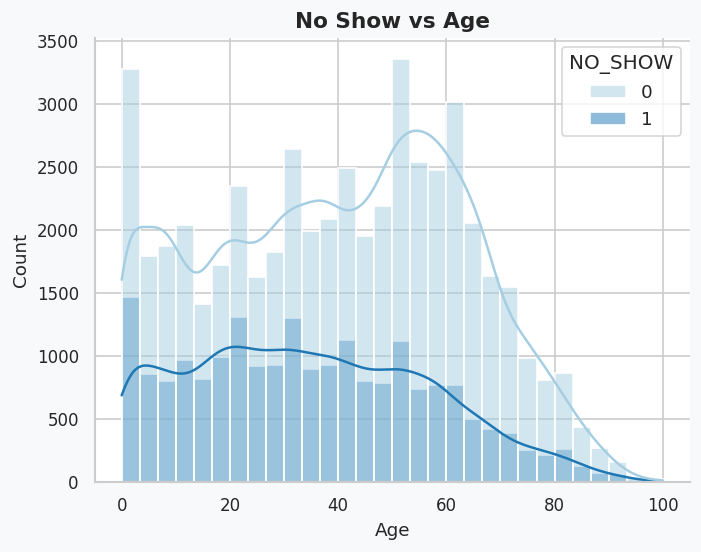

In [ ]:
# No show vs Age
sns.histplot(data=df, x='AGE', hue='NO_SHOW', bins=30, kde=True)

plt.title("No Show vs Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

In [ ]:
df.groupby('NO_SHOW')['AGE'].mean()

,AGE
NO_SHOW,
0,39.965375
1,34.833106


In [ ]:
# No shwo vs Gender
gender_no_show = pd.crosstab(df['GENDER'], df['NO_SHOW'])
print(gender_no_show)

NO_SHOW      0      1
GENDER               
F        34396  13674
M        17041   6848


<Figure size 720x480 with 0 Axes>

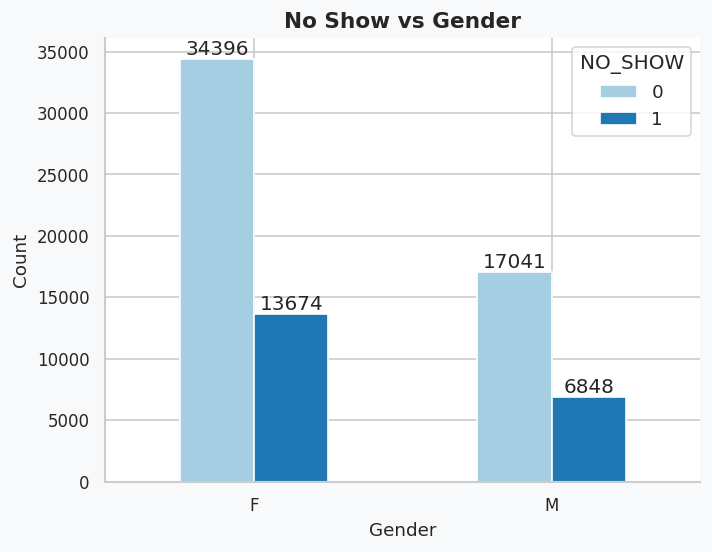

In [ ]:
plt.figure(figsize=(6,4))
ax=gender_no_show.plot(kind='bar')
for container in ax.containers:
    ax.bar_label(container)

plt.title("No Show vs Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

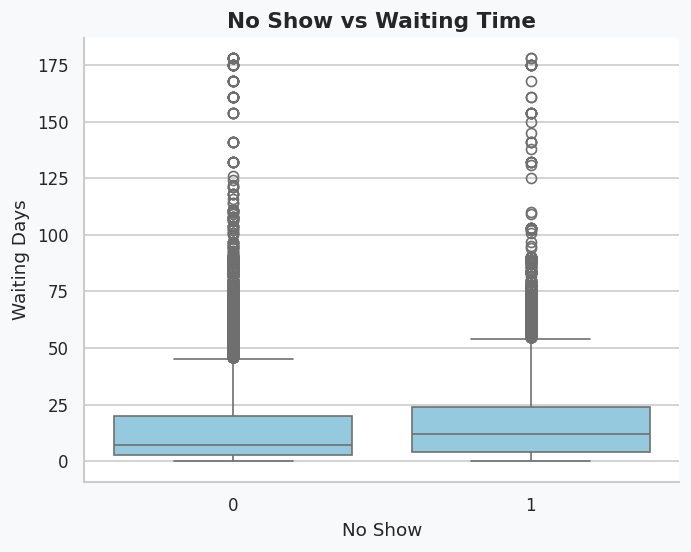

In [ ]:
sns.boxplot(x='NO_SHOW', y='WAITING_DAYS', data=df, color='skyblue')

plt.title("No Show vs Waiting Time")
plt.xlabel("No Show")
plt.ylabel("Waiting Days")
plt.show()

In [ ]:
# Average Waiting Time
df.groupby('NO_SHOW')['WAITING_DAYS'].mean()

,WAITING_DAYS
NO_SHOW,
0,14.013142
1,16.218254


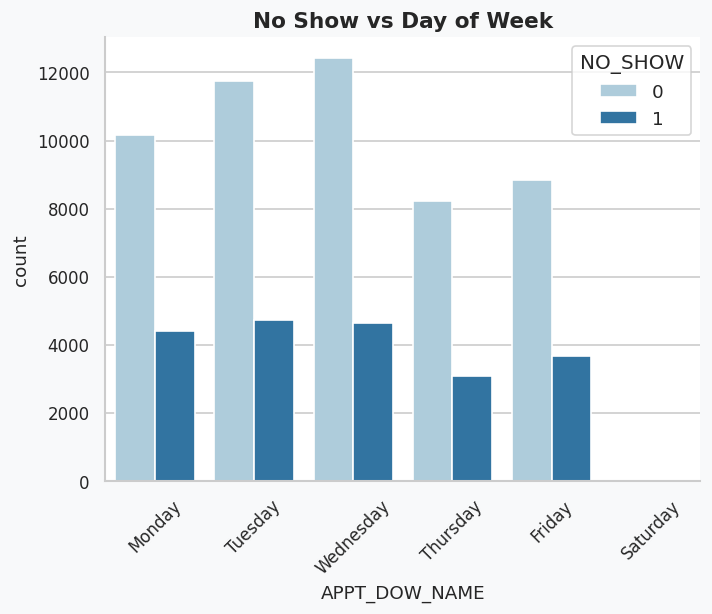

In [ ]:
# No Show vs Day of Week
sns.countplot(data=df,
              x='APPT_DOW_NAME',
              hue='NO_SHOW',
              order=['Monday','Tuesday','Wednesday',
                     'Thursday','Friday','Saturday'])

plt.title("No Show vs Day of Week")
plt.xticks(rotation=45)
plt.show()

NO_SHOW           0      1
SMS_RECEIVED              
0             25739  10738
1             25698   9784


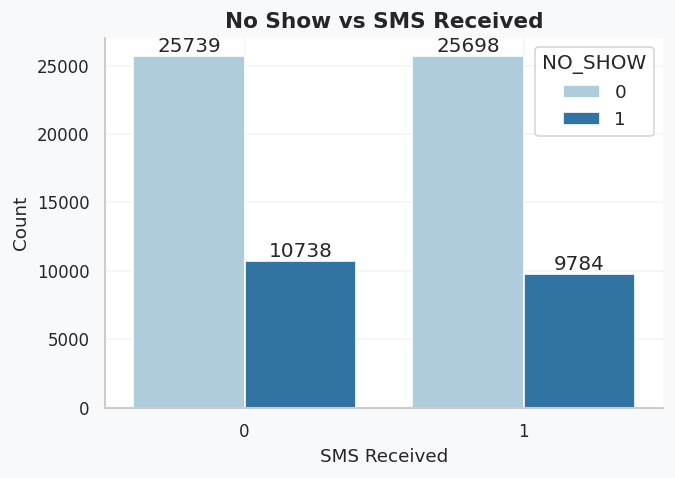

In [ ]:
# No Show vs SMS Received
sms_analysis = pd.crosstab(df['SMS_RECEIVED'], df['NO_SHOW'])
print(sms_analysis)

plt.figure(figsize=(6,4))
ax=sns.countplot(data=df, x='SMS_RECEIVED', hue='NO_SHOW')
for container in ax.containers:
    ax.bar_label(container)

plt.title("No Show vs SMS Received")
plt.xlabel("SMS Received")
plt.ylabel("Count")
plt.grid(True, alpha=0.2)
plt.show()

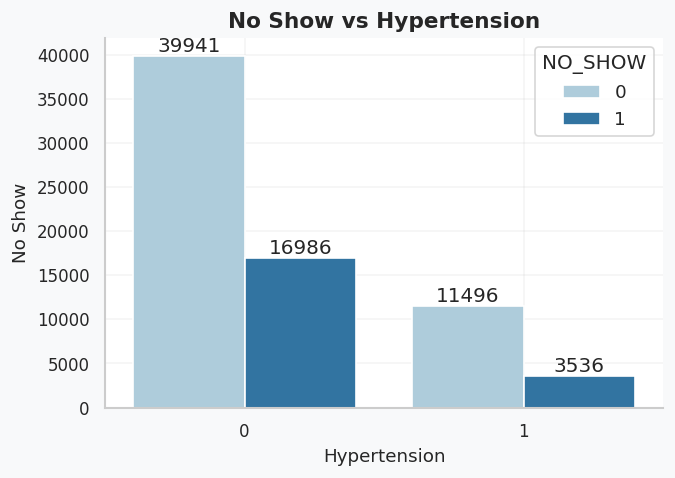

In [ ]:
# No Show vs Medical Condition
plt.figure(figsize=(6,4))
ax=sns.countplot(data=df, x='HYPERTENSION', hue='NO_SHOW')
for container in ax.containers:
  ax.bar_label(container)

plt.title("No Show vs Hypertension")
plt.xlabel("Hypertension")
plt.ylabel("No Show")
plt.grid(True, alpha=0.2)
plt.show()

In [ ]:
# High risk no show locations
location_risk = df.groupby('NEIGHBOURHOOD')['NO_SHOW'].mean()
location_risk = location_risk.sort_values(ascending=False)
print(location_risk.head(10))

NEIGHBOURHOOD
Ilhas Oceânicas De Trindade    1.000000
Gurigica                       0.383710
Jesus De Nazareth              0.374929
Itararé                        0.364973
Horto                          0.359649
Santos Dumont                  0.348917
Santa Clara                    0.338583
Santa Cecília                  0.335244
Ariovaldo Favalessa            0.325714
Ilha Do Príncipe               0.325349
Name: NO_SHOW, dtype: float64


# **Bivariate Analysis**
## **Numeric vs Numeric Analysis**

- **Age vs. Waiting Days:** the distribution is relatively uniform across the lifespan. However, there is a slight tapering of extremely long wait times (100+ days) for patients over the age of 80.

- **SMS Received vs. Waiting Days:** density of appointments for those who received an SMS (1) is much thicker in the mid-to-high wait ranges (above 25 days) compared to those who didn't. Many patients with very short wait times (0–5 days) do not receive an SMS.

- **Appointment Day vs. Waiting Days:** 2016-05-14 had almost no appointments scheduled, and those that were had very low wait times.

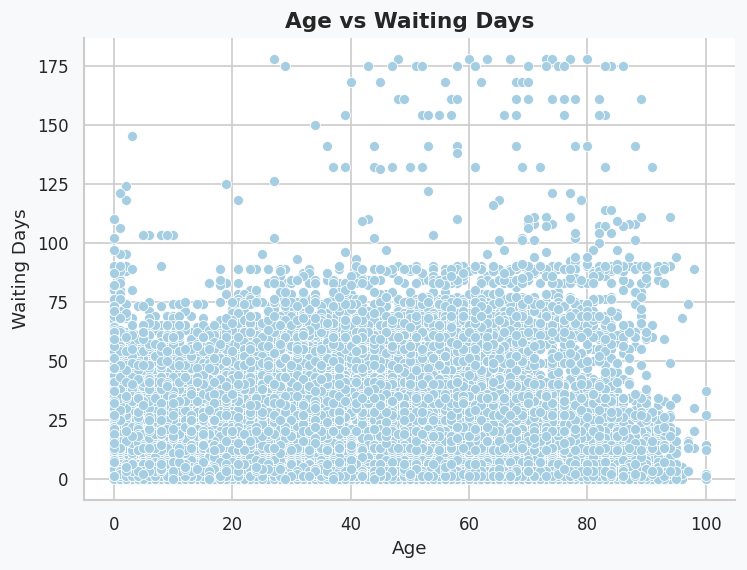

In [ ]:
# Age vs Waiting Days
plt.figure(figsize=(7,5))

sns.scatterplot(data=df, x='AGE', y='WAIT_DAYS')

plt.title("Age vs Waiting Days")
plt.xlabel("Age")
plt.ylabel("Waiting Days")

plt.show()

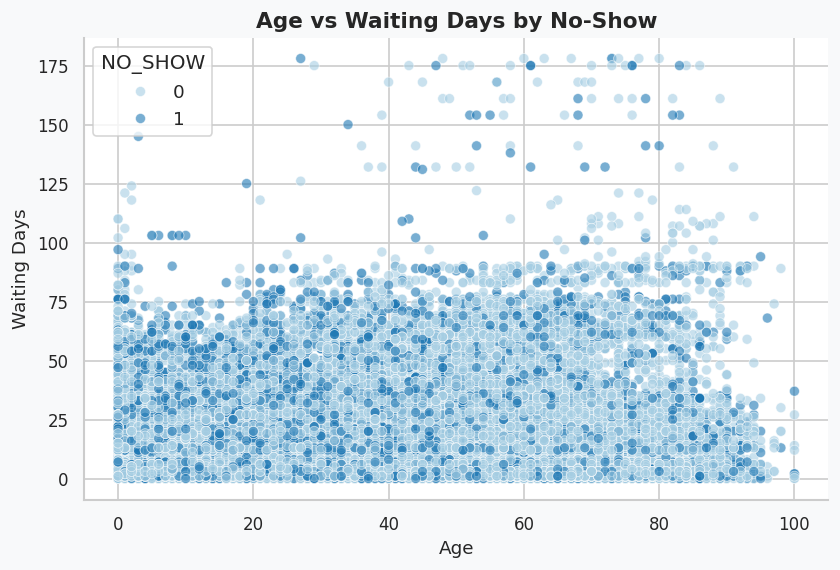

In [ ]:
# Age vs Waiting Day with No-Show
plt.figure(figsize=(8,5))

sns.scatterplot(data=df,
                x='AGE',
                y='WAIT_DAYS',
                hue='NO_SHOW',
                alpha=0.6)

plt.title("Age vs Waiting Days by No-Show")
plt.xlabel("Age")
plt.ylabel("Waiting Days")

plt.show()

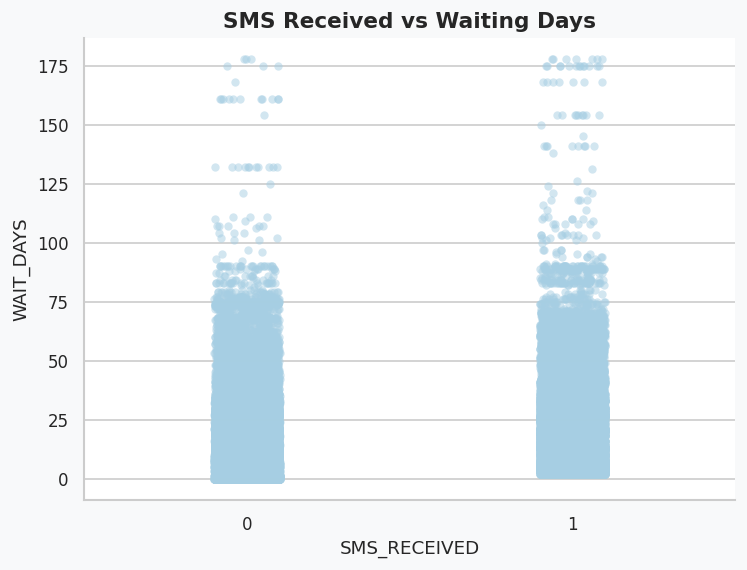

In [ ]:
# SMS Received vs Waiting Days
plt.figure(figsize=(7,5))

sns.stripplot(data=df,
              x='SMS_RECEIVED',
              y='WAIT_DAYS',
              jitter=True,
              alpha=0.5)

plt.title("SMS Received vs Waiting Days")

plt.show()

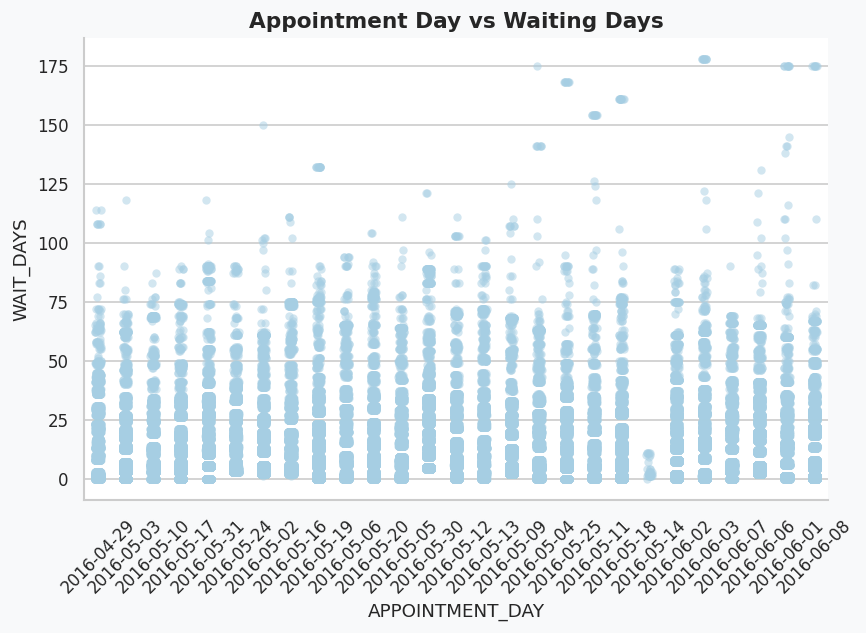

In [ ]:
# Appointment Day vs Waiting Days
plt.figure(figsize=(8,5))

sns.stripplot(data=df,
              x='APPOINTMENT_DAY',
              y='WAIT_DAYS',
              jitter=True,
              alpha=0.5)

plt.title("Appointment Day vs Waiting Days")

plt.xticks(rotation=45)

plt.show()

In [ ]:
print(df.columns)

Index(['PATIENT_ID', 'APPOINTMENT_ID', 'GENDER', 'SCHEDULED_DAY',
       'APPOINTMENT_DAY', 'AGE', 'NEIGHBOURHOOD', 'SCHOLARSHIP',
       'HYPERTENSION', 'DIABETES', 'ALCOHOLISM', 'HANDICAP', 'SMS_RECEIVED',
       'NO_SHOW', 'WAIT_DAYS', 'APPT_DOW', 'APPT_DOW_NAME',
       'COMORBIDITY_COUNT', 'AGE_GROUP', 'WAITING_DAYS'],
      dtype='object')


## **Correlation Matrix**

The correlation heatmap visualises the relationship between numerical variables in the dataset.

- Positive correlation values indicate that two variables increase together.
- Negative correlation values indicate an inverse relationship.
- Values close to zero indicate weak or no relationship.

In [ ]:
numeric_df = df[[
    'AGE',
    'WAIT_DAYS',
    'SCHOLARSHIP',
    'HYPERTENSION',
    'DIABETES',
    'ALCOHOLISM',
    'HANDICAP',
    'SMS_RECEIVED',
    'NO_SHOW'
]]

correlation_matrix = numeric_df.corr()
print(correlation_matrix)

                   AGE  WAIT_DAYS  SCHOLARSHIP  HYPERTENSION  DIABETES  \
AGE           1.000000  -0.008606    -0.103038      0.500802  0.284520   
WAIT_DAYS    -0.008606   1.000000    -0.026177     -0.051121 -0.048246   
SCHOLARSHIP  -0.103038  -0.026177     1.000000     -0.027764 -0.025417   
HYPERTENSION  0.500802  -0.051121    -0.027764      1.000000  0.425614   
DIABETES      0.284520  -0.048246    -0.025417      0.425614  1.000000   
ALCOHOLISM    0.080366  -0.029137     0.030529      0.085821  0.024174   
HANDICAP      0.083974  -0.016417    -0.010107      0.089588  0.063456   
SMS_RECEIVED -0.042523   0.201789     0.020666     -0.037065 -0.031219   
NO_SHOW      -0.101090   0.060362     0.045687     -0.056859 -0.022412   

              ALCOHOLISM  HANDICAP  SMS_RECEIVED   NO_SHOW  
AGE             0.080366  0.083974     -0.042523 -0.101090  
WAIT_DAYS      -0.029137 -0.016417      0.201789  0.060362  
SCHOLARSHIP     0.030529 -0.010107      0.020666  0.045687  
HYPERTENSION   

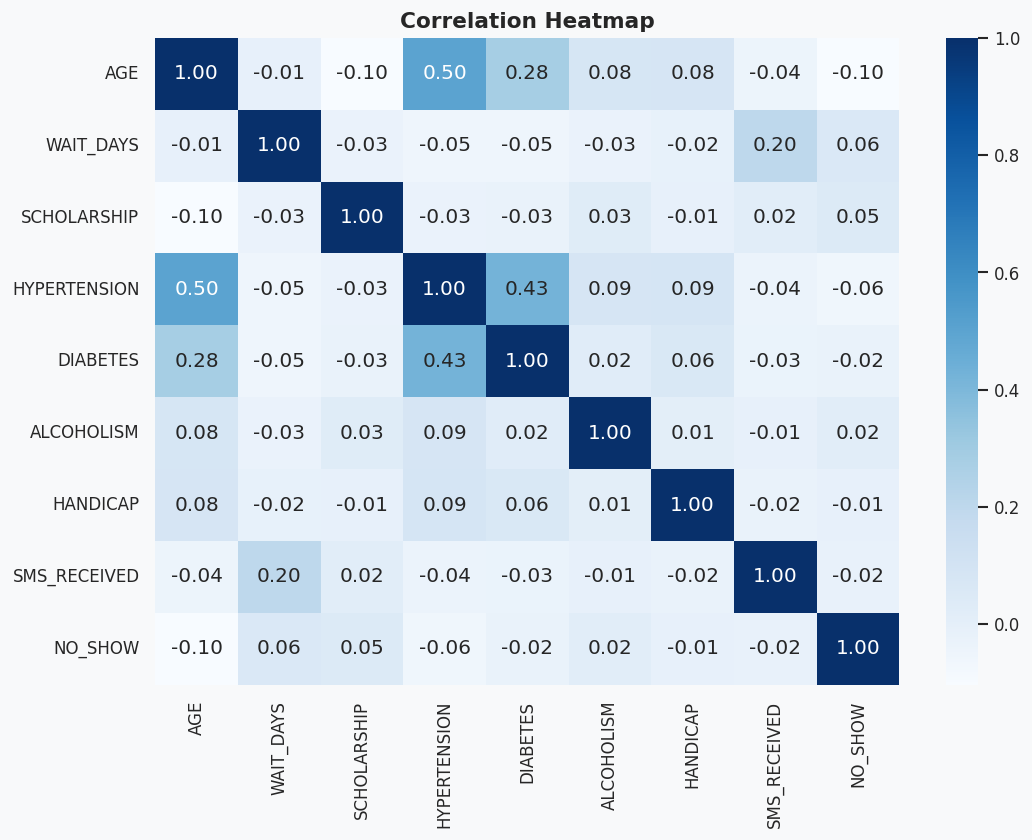

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(10,7))

sns.heatmap(correlation_matrix, annot=True, cmap='Blues', fmt='.2f')

plt.title("Correlation Heatmap")
plt.show()

## **Pearson Correlation Analysis**

Pearson correlation analysis was performed to evaluate the linear relationship between Age and Waiting Days.

### **Insights**
- Strong negative correlation between and age (-0.101) and No-Show, indicating younger generation are more likely to miss appointments.
- Strong positive correlation for wait days (+0.060). As wait days increase, chances of No-Show also increase significantly.
- Scholarship (+0.045) and Alcoholism (+0.019) patients have higher chance of missing appointments.
- Patients with Hypertension (-0.056) and Diabetes (-0.022) are highly likely to show up for their appointment

The provided P-value (0.021) is less than the standard significance level of 0.05.

This indicates that the correlations are statistically significant. They are not just random noise in the data; there is a real, measurable relationship between these features and the No-Show rate.

In [ ]:
# Pearson Correlation Analysis
corr, p_value = pearsonr(df['AGE'], df['WAIT_DAYS'])

print("Pearson Correlation Coefficient:", corr)
print("P-value:", p_value)

Pearson Correlation Coefficient: -0.008606252591615921
P-value: 0.020963291856501292


In [ ]:
target_corr = numeric_df.corr()['NO_SHOW'].sort_values(ascending=False)
print(target_corr)

NO_SHOW         1.000000
WAIT_DAYS       0.060362
SCHOLARSHIP     0.045687
ALCOHOLISM      0.019864
HANDICAP       -0.008930
SMS_RECEIVED   -0.020631
DIABETES       -0.022412
HYPERTENSION   -0.056859
AGE            -0.101090
Name: NO_SHOW, dtype: float64


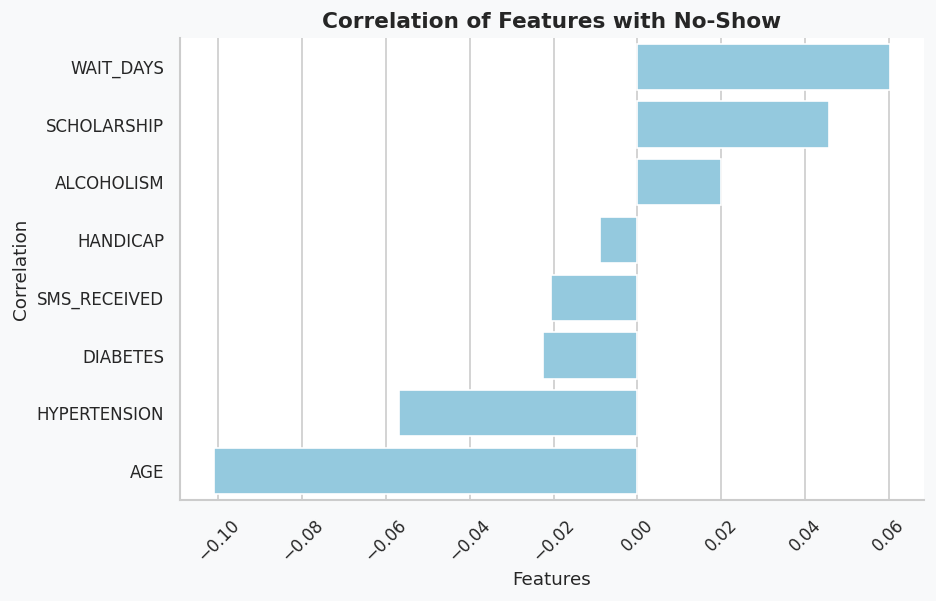

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=target_corr.drop('NO_SHOW').values,
    y=target_corr.drop('NO_SHOW').index, color='skyblue'
)

plt.title("Correlation of Features with No-Show")
plt.xlabel("Features")
plt.ylabel("Correlation")

plt.xticks(rotation=45)

plt.show()

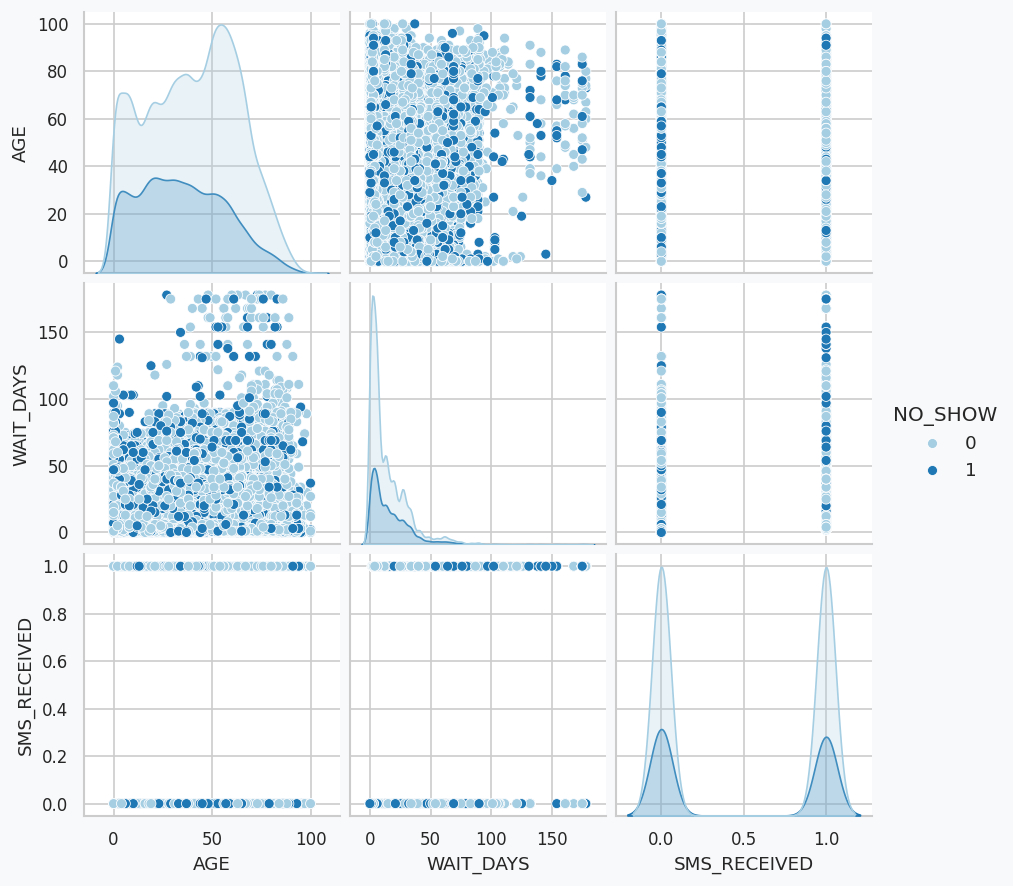

In [ ]:
sns.pairplot(df[['AGE', 'WAIT_DAYS', 'SMS_RECEIVED', 'NO_SHOW']], hue='NO_SHOW')

plt.show()

## **Regression Analysis**
**Ordinary Least Squares (OLS) Regression**

Performed using the `statsmodels` library in Python. In this model, we try to predict the number of Waiting Days based on a patient's Age.

**“coef” columns:**

- Intercept (const): 14.8804 . If a patient's age is 0, the model predicts they will wait about 15 days.
- Slope (AGE): -0.0062. For every one-year increase in age, the waiting time decreases by a very tiny amount (0.0062 days).
- $WAITDAYS=14.8804−(0.0062×AGE)$

**Statistical Significance**

- P>|t| (P-value) for AGE: 0.021. Because this is less than 0.05, the relationship is statistically significant. Age *does* have a measurable effect on waiting days that isn't just due to random chance.
- Prob (F-statistic): 0.0210. This confirms the overall model is significantly better than a model with no predictors.

**Model Fit**

- R-squared: 0.000. This is the most critical finding. While the relationship is "statistically significant," the R-squared of 0.000 (actually a value so small it rounded to zero) means that Age explains 0% of the variation in Waiting Days.
- Interpretation: Even though older people might wait slightly less on average, Age is a very poor predictor. There are clearly many other factors (like the specific clinic, the type of appointment, or the neighbourhood) that matter much more than age.


In [ ]:
# Linear Regression
X = df['AGE']
y = df['WAIT_DAYS']

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              WAIT_DAYS   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     5.330
Date:                Thu, 07 May 2026   Prob (F-statistic):             0.0210
Time:                        05:37:33   Log-Likelihood:            -3.0380e+05
No. Observations:               71959   AIC:                         6.076e+05
Df Residuals:                   71957   BIC:                         6.076e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         14.8804      0.120    123.805      0.0

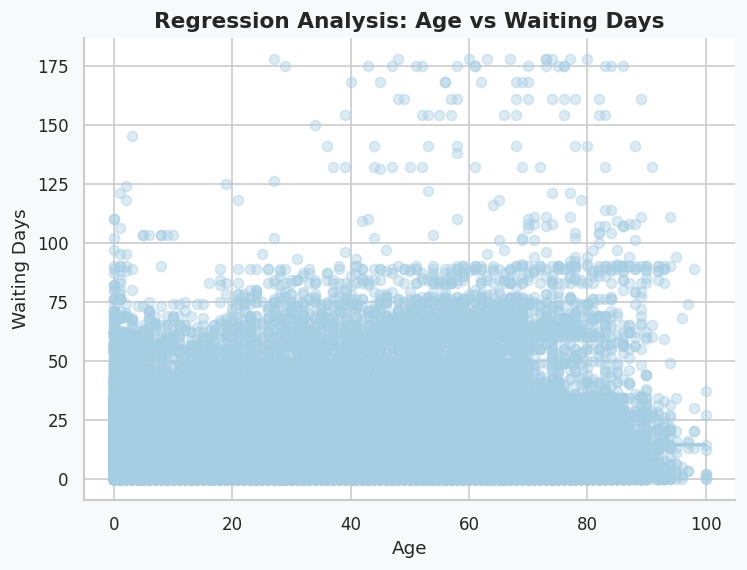

In [ ]:
plt.figure(figsize=(7,5))

sns.regplot(data=df,
            x='AGE',
            y='WAIT_DAYS',
            scatter_kws={'alpha':0.4})

plt.title("Regression Analysis: Age vs Waiting Days")
plt.xlabel("Age")
plt.ylabel("Waiting Days")

plt.show()

## **Pearson Correlation Analysis**
The Pearson Correlation Analysis identifies which patient features have a linear relationship with appointment NO_SHOW rates. All listed features are statistically significant (p < 0.05), meaning these trends are unlikely to be due to random chance.

**Positive Correlations**

- WAIT_DAYS (r = 0.0604): This is the strongest positive predictor. As the time between booking and the appointment increases, the likelihood of a patient missing the appointment also increases.

- SCHOLARSHIP (r = 0.0457): Patients enrolled in the scholarship (social welfare) program show a higher tendency to miss appointments, potentially due to socio-economic hurdles like transportation or work flexibility.

- ALCOHOLISM (r = 0.0199): Patients with recorded alcoholism are slightly more likely to be no-shows.

**Negative Correlations**

- AGE (r = -0.1011): This is the single strongest predictor in the entire dataset. Older patients are significantly more reliable and less likely to miss their appointments compared to younger patients.

- HYPERTENSION (r = -0.0569) & COMORBIDITY_COUNT (r = -0.0430): Patients with chronic health conditions or multiple diagnosed issues are more likely to show up. This suggests that patients with perceived high-risk health needs prioritize their medical visits.

- SMS_RECEIVED (r = -0.0206): Receiving a text reminder has a small but statistically significant impact on reducing no-show rates.



PEARSON CORRELATION
Measures the linear relationship between each numeric feature and NO_SHOW.
r is between -1 and +1. p < 0.05 means the result is statistically significant.

  AGE
    r = -0.1011   p = 9.3383e-163   – significant
  WAIT_DAYS
    r = 0.0604   p = 4.5278e-59   – significant
  HYPERTENSION
    r = -0.0569   p = 1.3173e-52   – significant
  DIABETES
    r = -0.0224   p = 1.8239e-09   – significant
  ALCOHOLISM
    r = 0.0199   p = 9.8828e-08   – significant
  SCHOLARSHIP
    r = 0.0457   p = 1.4512e-34   – significant
  HANDICAP
    r = -0.0089   p = 1.6602e-02   – significant
  SMS_RECEIVED
    r = -0.0206   p = 3.1157e-08   – significant
  COMORBIDITY_COUNT
    r = -0.0430   p = 9.2615e-31   – significant


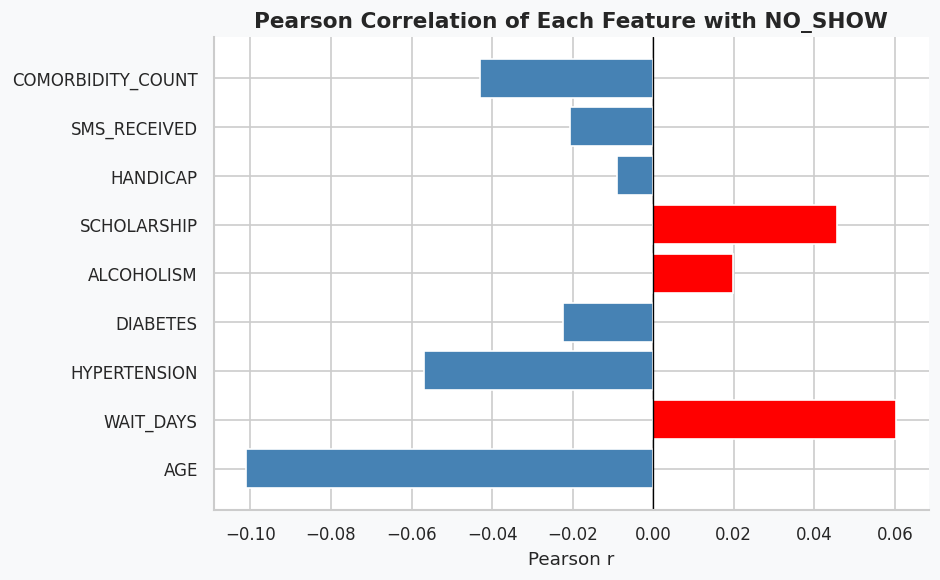

In [ ]:
print("\n\nPEARSON CORRELATION")
print("Measures the linear relationship between each numeric feature and NO_SHOW.")
print("r is between -1 and +1. p < 0.05 means the result is statistically significant.\n")

numeric_features = ['AGE', 'WAIT_DAYS', 'HYPERTENSION', 'DIABETES',
                    'ALCOHOLISM', 'SCHOLARSHIP', 'HANDICAP',
                    'SMS_RECEIVED', 'COMORBIDITY_COUNT']

for col in numeric_features:
    r, p = pearsonr(df[col], df['NO_SHOW'])
    significance = "significant" if p < 0.05 else "NOT significant"
    print(f"  {col}")
    print(f"    r = {r:.4f}   p = {p:.4e}   – {significance}")


# Pearson correlation bar chart
r_values = []
for col in numeric_features:
    r, p = pearsonr(df[col], df['NO_SHOW'])
    r_values.append(r)

plt.figure(figsize=(8, 5))
colors = ['red' if v > 0 else 'steelblue' for v in r_values]
plt.barh(numeric_features, r_values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel("Pearson r")
plt.title("Pearson Correlation of Each Feature with NO_SHOW")
plt.tight_layout()
plt.show()

## **Linear Regression**

The OLS output defines a clear mathematical relationship:

$NOSHOW=0.2610+(0.0017×WAITDAYS)$

- Baseline Risk (Intercept): Even if an appointment is booked for the same day (0 days wait), there is a 26.1% baseline probability of a no-show.
- The Growth Factor: For every single day added to the waiting period, the probability of a no-show increases by 0.1652%. While this seems small, over a 30-day wait, the risk increases by nearly 5% above the baseline.

There is a major distinction here between "certainty" and "accuracy":

- Highly Significant: The P-value is effectively 0.000 (4.53e−59). This means we are absolutely certain that waiting time affects no-show rates; it isn't just a fluke in the data.
- Low Predictive Power (R2): The R−squared value is only 0.004 (0.4%). This indicates that while wait time is a factor, it explains less than 1% of the total reason why people miss appointments. Thousands of other factors (illness, weather, work, etc.) make up the other 99%.


The scatter plot with the red regression line visualizes this "weak but steady" trend:

- Upward Slope: You can clearly see the red line climbing as it moves to the right. By the time a patient has waited 175 days, their probability of a no-show has climbed from the 26% baseline to roughly 55%.
- Binary Clustering: The data points are clustered at the top (1.0) and bottom (0.0) because a person either shows up or they don't. The red line represents the *average probability* across all those individuals.

In [ ]:
print("\nREGRESSION ANALYSIS")

print("\nSimple Linear Regression: WAIT_DAYS – NO_SHOW")

X_simple = sm.add_constant(df['WAIT_DAYS'])
model_simple = sm.OLS(df['NO_SHOW'], X_simple).fit()
print(model_simple.summary())

b0 = model_simple.params['const']
b1 = model_simple.params['WAIT_DAYS']
print(f"\nEquation: NO_SHOW = {b0:.4f} + {b1:.6f} x WAIT_DAYS")
print(f"Every extra day of waiting increases no-show probability by {b1*100:.4f}%")


REGRESSION ANALYSIS

Simple Linear Regression: WAIT_DAYS – NO_SHOW
                            OLS Regression Results                            
Dep. Variable:                NO_SHOW   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     263.1
Date:                Thu, 07 May 2026   Prob (F-statistic):           4.53e-59
Time:                        07:07:54   Log-Likelihood:                -44755.
No. Observations:               71959   AIC:                         8.951e+04
Df Residuals:                   71957   BIC:                         8.953e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------

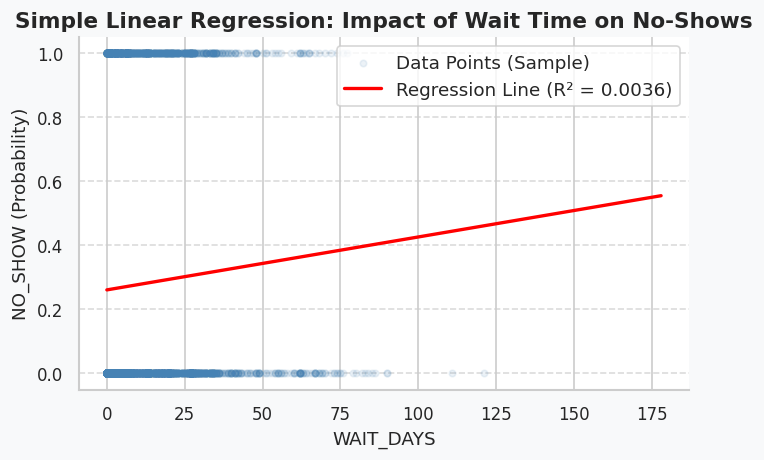

In [ ]:
plt.figure(figsize=(6, 4))

x_line = np.linspace(0, df['WAIT_DAYS'].max(), 200)
y_line = b0 + b1 * x_line

sample = df.sample(min(3000, len(df)), random_state=1)
plt.scatter(sample['WAIT_DAYS'], sample['NO_SHOW'], alpha=0.1, color='steelblue', s=15, label="Data Points (Sample)")

plt.plot(x_line, y_line, color='red', linewidth=2, label=f"Regression Line (R² = {model_simple.rsquared:.4f})")

plt.xlabel("WAIT_DAYS")
plt.ylabel("NO_SHOW (Probability)")
plt.title("Simple Linear Regression: Impact of Wait Time on No-Shows")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## **T-Test**

1. Age: The Maturity Factor

- Insight: Older patients are significantly more reliable.

- Data Evidence: The mean age for those who "Showed Up" is roughly 40 years, compared to 35 years for "No-Shows."

- Visual Evidence: In the first box plot, the blue box (Showed Up) sits visibly higher on the Y-axis. The p-value (1.89×10
−169
 ) is extremely low, meaning this is a very strong and consistent trend across the dataset.

2. Wait Days: The "Forgetfulness" Gap

- Insight: The longer a patient has to wait for their appointment, the more likely they are to miss it.

- Data Evidence: Patients who showed up had an average wait of 14 days, while no-shows averaged over 16 days.

- Visual Evidence: While both groups have many "same-day" appointments (the boxes are low), the red box (No-Show) has a higher median and a denser cluster of outliers reaching up to 175 days. The t-statistic of -16.13 confirms that this 2-day difference in means is highly significant.

3. Comorbidity Count: Health Stakes

- Insight: Patients with more chronic health conditions (comorbidities) are more likely to attend their appointments.

- Data Evidence: Those who "Showed Up" have a higher mean comorbidity count (0.325) than those who missed their visit (0.268).

- Interpretation: Patients with complex health needs likely perceive their medical visits as more "high-stakes" or essential for their daily survival, leading to better compliance.

In [ ]:
showed_up = df[df['NO_SHOW'] == 0]
no_show   = df[df['NO_SHOW'] == 1]

ttest_features = ['AGE', 'WAIT_DAYS', 'COMORBIDITY_COUNT']

for col in ttest_features:
    g0 = showed_up[col].dropna()
    g1 = no_show[col].dropna()
    t_stat, p_val = ttest_ind(g0, g1, equal_var=False)   # Welch's t-test

    # Cohen's d measures practical effect size
    pooled_std = np.sqrt((g0.std()**2 + g1.std()**2) / 2)
    cohens_d = (g1.mean() - g0.mean()) / pooled_std

    significance = "significant" if p_val < 0.05 else "NOT significant"
    print(f"  {col}")
    print(f"    Mean (Showed Up)  = {g0.mean():.3f}")
    print(f"    Mean (No-Show)    = {g1.mean():.3f}")
    print(f"    t-statistic       = {t_stat:.4f}")
    print(f"    p-value           = {p_val:.4e}  – {significance}")
    print()

  AGE
    Mean (Showed Up)  = 39.965
    Mean (No-Show)    = 34.833
    t-statistic       = 27.8825
    p-value           = 1.8878e-169  – significant

  WAIT_DAYS
    Mean (Showed Up)  = 14.013
    Mean (No-Show)    = 16.218
    t-statistic       = -16.1334
    p-value           = 2.3436e-58  – significant

  COMORBIDITY_COUNT
    Mean (Showed Up)  = 0.325
    Mean (No-Show)    = 0.268
    t-statistic       = 11.8954
    p-value           = 1.4179e-32  – significant



/tmp/ipykernel_846/2163524580.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data_groups, labels=['Showed Up', 'No-Show'],
/tmp/ipykernel_846/2163524580.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data_groups, labels=['Showed Up', 'No-Show'],
/tmp/ipykernel_846/2163524580.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data_groups, labels=['Showed Up', 'No-Show'],


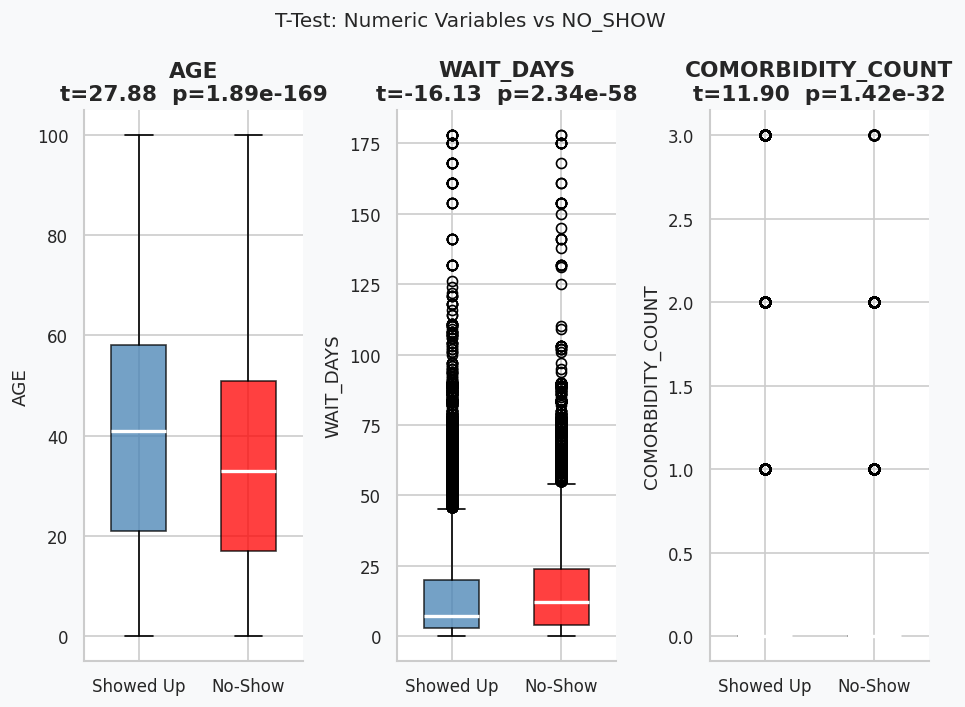

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(8, 6))
fig.suptitle("T-Test: Numeric Variables vs NO_SHOW", fontsize=12)

for i, col in enumerate(ttest_features):
    data_groups = [showed_up[col].values, no_show[col].values]
    bp = axes[i].boxplot(data_groups, labels=['Showed Up', 'No-Show'],
                         patch_artist=True, widths=0.5,
                         medianprops=dict(color='white', linewidth=2))
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][1].set_facecolor('red')
    for box in bp['boxes']:
        box.set_alpha(0.75)

    t_stat, p_val = ttest_ind(showed_up[col], no_show[col], equal_var=False)
    axes[i].set_title(f"{col}\nt={t_stat:.2f}  p={p_val:.2e}")
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()